# Experiment 000C: Global Throttle With Quantization

This notebook extends the one-layer global-throttle sanity test with fake fixed-point quantization.

Goals:

1. Validate that the new `kappa.dtypes`, `PrecisionDict`, and quantization hooks behave coherently.
2. Repeat the Experiment 000 drift ablation with quantization enabled.
3. Identify whether failures come from saturation, update underflow, or closed-loop curvature.

This notebook should remain small and explicit. The point is diagnosis, not performance.

## Setup

We use the same dataset/model as Experiment 000:

$$y = Ax$$

$$\hat{y} = Wx$$

and then introduce input gain drift:

$$x_{\mathrm{drift}} = \gamma x.$$

In [1]:
import os, sys 
# Define a little helper function that searches UP the tree until it finds a folder named "kappa" and adds it to the path. This allows us to import kappa from anywhere in the workspace without worrying about relative paths.
def recursive_dir(path):
    if 'kappa' in os.listdir(path): return path
    parent_dir = os.path.dirname(path)
    if parent_dir == path:  raise FileNotFoundError("Could not find a folder named 'kappa' in the directory tree.")
    return recursive_dir(parent_dir)
def add_kappa_to_path(): p = recursive_dir(os.getcwd()); sys.path.append(p); print(f'[INFO] Added {p} to path.')
add_kappa_to_path()
# Import kappa after adding it to the path
import kappa

[INFO] Added /Users/mbvalentin/kappa_budgeting to path.


[INFO] - κ-budgeting package imported successfully! Version: 0.1.0, URL: https://manuelblancovalentin.github.io/kappa_budgeting/


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from kappa import dtypes, PrecisionDict

In [3]:
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 0
N = 1000
GAMMA = 4.0
ETA = 0.5
CHI = 1.5

## Build Dataset And Model

In [4]:
dataset = kappa.AffineDataset(num_samples=N, use_bias=False, seed=SEED)
X, Y = dataset.get()

Xd = GAMMA * X
Yd = Y

print(dataset)
print(dataset.analytic_hessian)

AffineDataset(
 [Input] X: 
    Shape: (1000, 4)
    Dtype: DataType.D2_FLOAT
    X <- Uniform(-1, 1)
 [Output] Y: 
    Shape: (1000, 2)
    Dtype: DataType.D2_FLOAT
    Y <- X @ A.T + b
 ---------
  A = [[ 1.25 -0.75  0.5   0.2 ]
       [-0.4   0.9   1.1  -0.6 ]]
  b = [0. 0.]
----------
Analytic Hessian:
  Lambda max: 1.0618
  Eta max: 1.8836
)
{'hessian': array([[0.33296713, 0.24657245, 0.2426763 , 0.24567218, 0.        ,
        0.        , 0.        , 0.        ],
       [0.24657245, 0.33718578, 0.24024673, 0.24988068, 0.        ,
        0.        , 0.        , 0.        ],
       [0.2426763 , 0.24024673, 0.31994652, 0.23878326, 0.        ,
        0.        , 0.        , 0.        ],
       [0.24567218, 0.24988068, 0.23878326, 0.32872459, 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.33296713,
        0.24657245, 0.2426763 , 0.24567218],
       [0.        , 0.        , 0.        , 0.        , 0.24657245,
      

In [5]:
model = kappa.LinearBlockModel(
    dataset=dataset,
    num_hidden=[dataset.A.shape[0]],
    activation=None,
    use_batchnorm=False,
    use_bias=False,
    seed=SEED,
)

model.summary()
print([layer.name for layer in model.model.layers])

Model: "LinearBlockModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ model_input (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense0 (Dense)                  │ (None, 2)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (32.00 B)

 Trainable params: 8 (32.00 B)

 Non-trainable params: 0 (0.00 B)

['model_input', 'dense0']


## Precision Maps

We start with explicit precision maps. Missing fields mean floating point.

The staged ablation should begin with:

1. weight quantization only,
2. update quantization only,
3. weights + updates,
4. full wide-rail fake fixed-point,
5. full tight-rail fake fixed-point.

In [6]:
def make_precision_map(kind):
    wide_weight = dtypes.ap_fixed(WL=16, IWL=6, QMODE="AP_RND", OMODE="AP_SAT")
    wide_activation = dtypes.ap_fixed(WL=16, IWL=8, QMODE="AP_RND", OMODE="AP_SAT")
    wide_gradient = dtypes.ap_fixed(WL=20, IWL=8, QMODE="AP_RND", OMODE="AP_SAT")
    wide_update = dtypes.ap_fixed(WL=20, IWL=6, QMODE="AP_RND", OMODE="AP_SAT")
    wide_accumulator = dtypes.ap_fixed(WL=28, IWL=14, QMODE="AP_RND", OMODE="AP_SAT")
    wide_loss = dtypes.ap_fixed(WL=32, IWL=16, QMODE="AP_RND", OMODE="AP_SAT")

    tight_weight = dtypes.ap_fixed(WL=8, IWL=3, QMODE="AP_RND", OMODE="AP_SAT")
    tight_activation = dtypes.ap_fixed(WL=8, IWL=4, QMODE="AP_RND", OMODE="AP_SAT")
    tight_gradient = dtypes.ap_fixed(WL=10, IWL=4, QMODE="AP_RND", OMODE="AP_SAT")
    tight_update = dtypes.ap_fixed(WL=10, IWL=2, QMODE="AP_RND", OMODE="AP_SAT")
    tight_accumulator = dtypes.ap_fixed(WL=14, IWL=6, QMODE="AP_RND", OMODE="AP_SAT")
    tight_loss = dtypes.ap_fixed(WL=16, IWL=8, QMODE="AP_RND", OMODE="AP_SAT")

    if kind == "float":
        return None

    if kind == "weight_only":
        return PrecisionDict({"dense0": {"weight": wide_weight}})

    if kind == "update_only":
        return PrecisionDict({"dense0": {"update": wide_update}})

    if kind == "weight_update":
        return PrecisionDict({"dense0": {"weight": wide_weight, "update": wide_update}})

    if kind == "full_wide":
        return PrecisionDict({
            "input": {"value": wide_activation},
            "dense0": {
                "weight": wide_weight,
                "activation": wide_activation,
                "gradient": wide_gradient,
                "update": wide_update,
                "accumulator": wide_accumulator,
            },
            "loss": {"value": wide_loss},
        })

    if kind == "full_tight":
        return PrecisionDict({
            "input": {"value": tight_activation},
            "dense0": {
                "weight": tight_weight,
                "activation": tight_activation,
                "gradient": tight_gradient,
                "update": tight_update,
                "accumulator": tight_accumulator,
            },
            "loss": {"value": tight_loss},
        })

    raise ValueError(kind)

## Mechanism Validation 1: Dtype Quantization

Before training, validate a few dtype objects directly. We want to see the rails, the quantum, and the saturation behavior.

wide_weight ap_fixed<16,6,AP_RND,AP_SAT> range= (-32.0, 31.9990234375) quantum= 0.0009765625


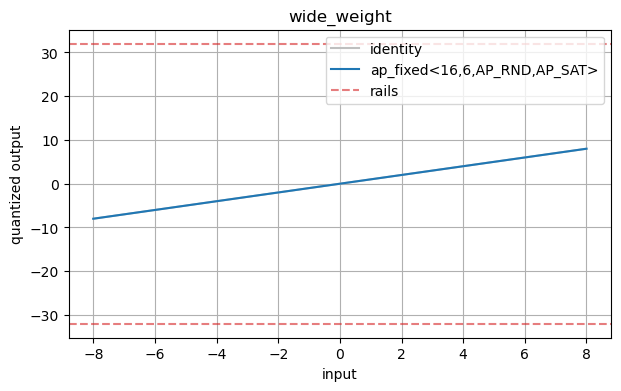

tight_weight ap_fixed<8,3,AP_RND,AP_SAT> range= (-4.0, 3.96875) quantum= 0.03125


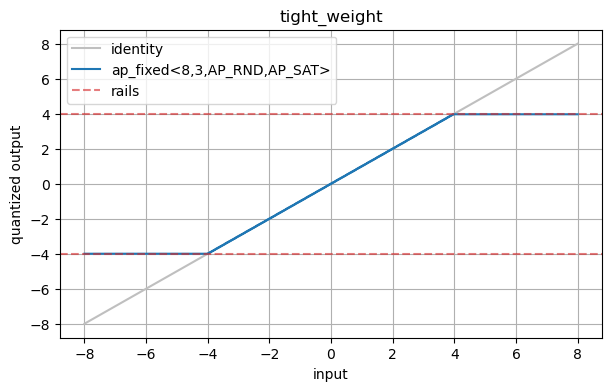

tight_update ap_fixed<10,2,AP_RND,AP_SAT> range= (-2.0, 1.99609375) quantum= 0.00390625


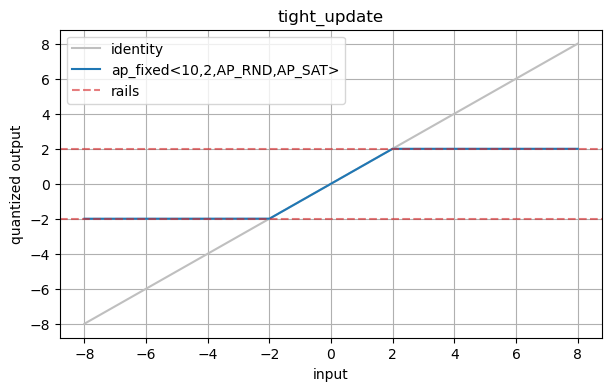

In [7]:
def plot_dtype_transfer(dtype, x_min=-8, x_max=8, n=2000, title=None):
    x = np.linspace(x_min, x_max, n)
    xq = dtype(x)
    lo, hi = dtype.value_range()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(x, x, color="0.75", label="identity")
    ax.plot(x, xq, label=str(dtype))
    ax.axhline(lo, linestyle="--", color="tab:red", alpha=0.6, label="rails")
    ax.axhline(hi, linestyle="--", color="tab:red", alpha=0.6)
    ax.set_xlabel("input")
    ax.set_ylabel("quantized output")
    ax.set_title(title or str(dtype))
    ax.grid(True)
    ax.legend()
    return fig, ax

for name, dtype in {
    "wide_weight": dtypes.ap_fixed(16, 6, "AP_RND", "AP_SAT"),
    "tight_weight": dtypes.ap_fixed(8, 3, "AP_RND", "AP_SAT"),
    "tight_update": dtypes.ap_fixed(10, 2, "AP_RND", "AP_SAT"),
}.items():
    print(name, dtype, "range=", dtype.value_range(), "quantum=", getattr(dtype, "quantum", None))
    fig, _ = plot_dtype_transfer(dtype, title=name)
    fig.savefig(RESULTS_DIR / f"000c_dtype_transfer_{name}.png", dpi=160, bbox_inches="tight")
    plt.show()

## Mechanism Validation 2: PrecisionDict And Layer Names

The precision dictionary should match stable model layer names. Missing fields should intentionally mean floating point.

In [8]:
for kind in ["weight_only", "update_only", "weight_update", "full_wide", "full_tight"]:
    p = make_precision_map(kind)
    p.validate_model(model.model)
    print("\n", kind)
    print(p.describe())


 weight_only
PrecisionDict(
  dense0:
    weight: ap_fixed<16,6,AP_RND,AP_SAT>
)

 update_only
PrecisionDict(
  dense0:
    update: ap_fixed<20,6,AP_RND,AP_SAT>
)

 weight_update
PrecisionDict(
  dense0:
    weight: ap_fixed<16,6,AP_RND,AP_SAT>
    update: ap_fixed<20,6,AP_RND,AP_SAT>
)

 full_wide
PrecisionDict(
  input:
    value: ap_fixed<16,8,AP_RND,AP_SAT>
  dense0:
    weight: ap_fixed<16,6,AP_RND,AP_SAT>
    activation: ap_fixed<16,8,AP_RND,AP_SAT>
    gradient: ap_fixed<20,8,AP_RND,AP_SAT>
    update: ap_fixed<20,6,AP_RND,AP_SAT>
    accumulator: ap_fixed<28,14,AP_RND,AP_SAT>
  loss:
    value: ap_fixed<32,16,AP_RND,AP_SAT>
)

 full_tight
PrecisionDict(
  input:
    value: ap_fixed<8,4,AP_RND,AP_SAT>
  dense0:
    weight: ap_fixed<8,3,AP_RND,AP_SAT>
    activation: ap_fixed<8,4,AP_RND,AP_SAT>
    gradient: ap_fixed<10,4,AP_RND,AP_SAT>
    update: ap_fixed<10,2,AP_RND,AP_SAT>
    accumulator: ap_fixed<14,6,AP_RND,AP_SAT>
  loss:
    value: ap_fixed<16,8,AP_RND,AP_SAT>
)


## Training Helper

Each run reinitializes the model, performs the nominal warmup, then enters the drifted phase. This mirrors Experiment 000.

In [9]:
def run_warmup_then_drift(label, precision_dict=None, use_controller=True, drift_epochs=100):
    model.reinitialize_weights()

    h_nom = model.train_instrumented(
        X,
        Y,
        epochs=20,
        batch_size=len(X),
        learning_rate=ETA,
        use_controller=False,
        compute_analytic_hessian=True,
        reference_A=dataset.reference_weight_matrix,
        precision_dict=precision_dict,
    )

    h_drift = model.train_instrumented(
        Xd,
        Yd,
        epochs=drift_epochs,
        batch_size=len(Xd),
        learning_rate=ETA,
        use_controller=use_controller,
        compute_analytic_hessian=True,
        reference_A=dataset.reference_weight_matrix / GAMMA,
        precision_dict=precision_dict,
    )

    return {"label": label, "warmup": h_nom, "drift": h_drift, "precision": precision_dict}

## Plotting Helpers

We keep the plots compact but add quantization-specific panels: rail pressure, update underflow, actual applied update norm, and update direction cosine.

In [10]:
def plot_drift_comparison(runs, title, filename):
    fig, axs = plt.subplots(4, 3, figsize=(15, 14), sharex=True)
    fig.suptitle(title)

    panels = [
        ("loss", "Loss", None),
        ("weight_error_fro", r"$||W-W^*||_F$", None),
        ("grad_norm", r"$||G||_2$", None),
        ("alpha", r"$\alpha_t$", None),
        ("stability_margin_lambda_raw", r"raw $\eta\lambda_{max}$", 2.0),
        ("stability_margin_lambda_ctrl", r"ctrl $\alpha\eta\lambda_{max}$", 2.0),
        ("raw_update_norm", r"$||\Delta\theta_{raw}||_2$", None),
        ("actual_update_norm", r"$||\Delta\theta_{actual}||_2$", None),
        ("update_cosine", r"cos$(\Delta\theta_{actual}, \Delta\theta_{raw})$", 1.0),
        ("weight_saturation_fraction_max", "weight saturation", None),
        ("gradient_saturation_fraction_max", "gradient saturation", None),
        ("update_underflow_fraction_max", "update underflow", None),
    ]

    for ax, (key, label, hline) in zip(axs.flat, panels):
        for run in runs:
            h = run["drift"]
            if key in h:
                ax.plot(h[key], label=run["label"])
        if hline is not None:
            ax.axhline(hline, linestyle="--", color="black", alpha=0.5)
        if key == "update_cosine":
            ax.set_ylim(-1.05, 1.05)
        ax.set_title(label)
        ax.grid(True)

    axs[0, 0].legend()
    for ax in axs[-1, :]:
        ax.set_xlabel("step")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(RESULTS_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()
    return fig

## Update Phase Distortion Helper

This is an offline diagnostic. It maps the update distortion into a polar point:

$$\beta_t = \arccos(c_t)$$

$$r_t = \frac{\|\Delta\theta_{actual}\|_2}{\|\Delta\theta_{raw}\|_2 + \epsilon}$$

$$p_t = r_t e^{i\beta_t}.$$

Healthy updates should stay near the positive real axis. Update underflow collapses the radius toward zero. Direction distortion pushes points away from the real axis.

In [11]:
def plot_update_phase(runs, title, filename):
    fig, ax = plt.subplots(figsize=(7, 7))

    theta = np.linspace(0.0, np.pi, 256)
    for radius in [0.25, 0.5, 1.0, 1.5]:
        ax.plot(
            radius * np.cos(theta),
            radius * np.sin(theta),
            color="lightgray",
            linewidth=0.8,
            zorder=0,
        )
        ax.text(radius, 0.02, f"r={radius:g}", fontsize=8, color="gray")

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for idx, run in enumerate(runs):
        h = run["drift"]
        if "update_angle_rad" in h and "update_radius_ratio" in h:
            beta = np.asarray(h["update_angle_rad"])
            radius = np.asarray(h["update_radius_ratio"])
        else:
            cosine = np.clip(np.asarray(h["update_cosine"]), -1.0, 1.0)
            beta = np.arccos(cosine)
            radius = np.asarray(h["actual_update_norm"]) / (np.asarray(h["raw_update_norm"]) + 1e-12)

        x = radius * np.cos(beta)
        y = radius * np.sin(beta)
        color = colors[idx % len(colors)]
        ax.plot(x, y, color=color, linewidth=1.2, alpha=0.7, label=run["label"])
        ax.scatter(x, y, color=color, s=12, alpha=0.45)
        if len(x) > 0:
            ax.scatter(x[0], y[0], color=color, marker="o", s=70, edgecolor="black", linewidth=0.6, zorder=3)
            ax.scatter(x[-1], y[-1], color=color, marker="X", s=80, edgecolor="black", linewidth=0.6, zorder=3)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel(r"$r_t \cos(\beta_t)$")
    ax.set_ylabel(r"$r_t \sin(\beta_t)$")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True)
    ax.legend(loc="upper right")
    ax.text(0.02, 0.98, "circle=start, X=end", transform=ax.transAxes, va="top", fontsize=9)
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()
    return fig

## 000C.0: Float Reproduction

This should reproduce the Experiment 000 controller behavior. It is the baseline for all quantized comparisons.

[INFO] - Reinitialized kernel for layer dense0 with initializer GlorotUniform


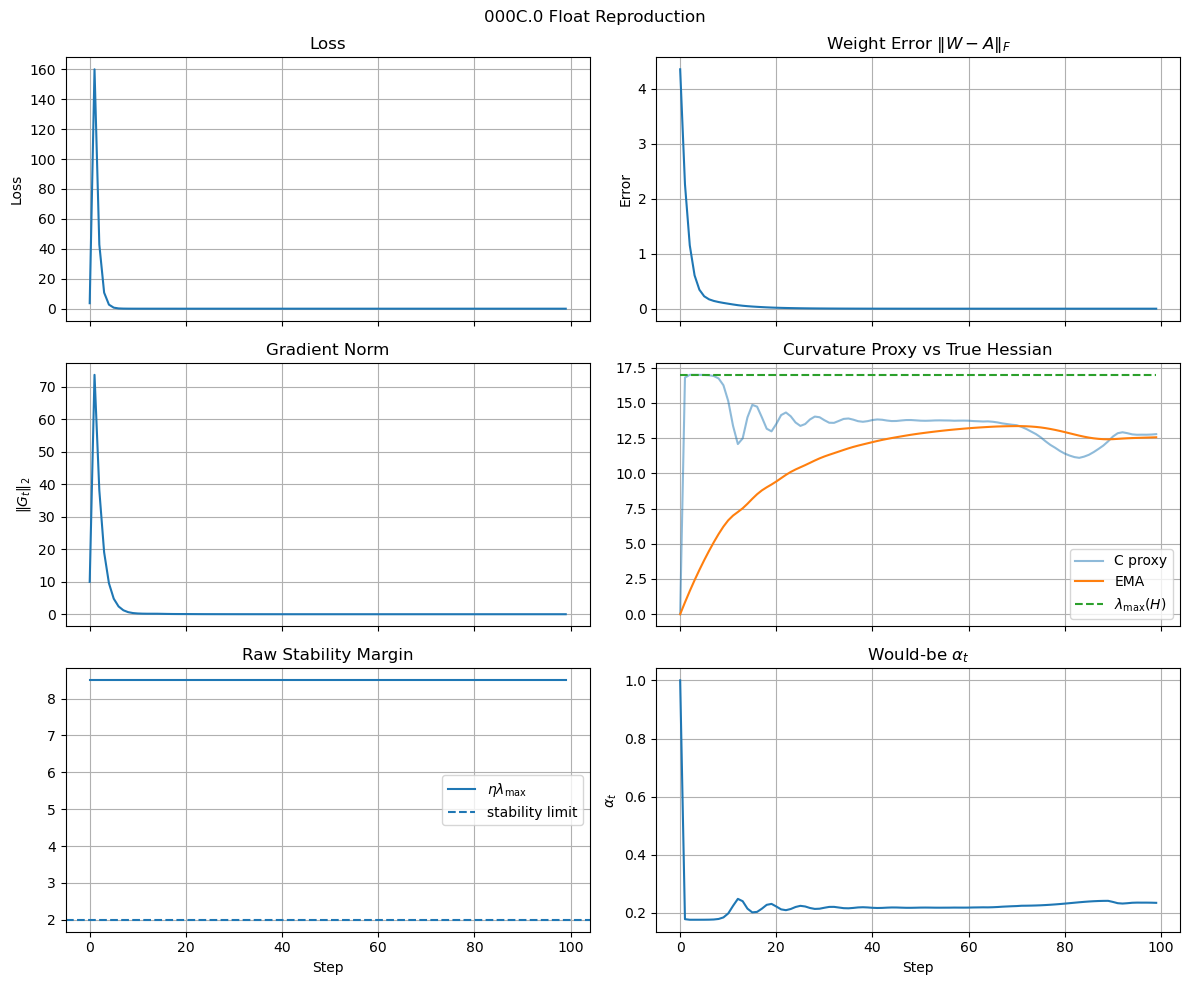

In [12]:
float_run = run_warmup_then_drift(
    label="float + controller",
    precision_dict=None,
    use_controller=True,
)

float_run["drift"].plot_results(title="000C.0 Float Reproduction")

## 000C.1-000C.3: Isolated Quantization Paths

These runs isolate whether stored weights, quantized updates, or their combination change the behavior before we turn on full fake-fixed-point quantization.

[INFO] - Reinitialized kernel for layer dense0 with initializer GlorotUniform


[INFO] - Reinitialized kernel for layer dense0 with initializer GlorotUniform


[INFO] - Reinitialized kernel for layer dense0 with initializer GlorotUniform


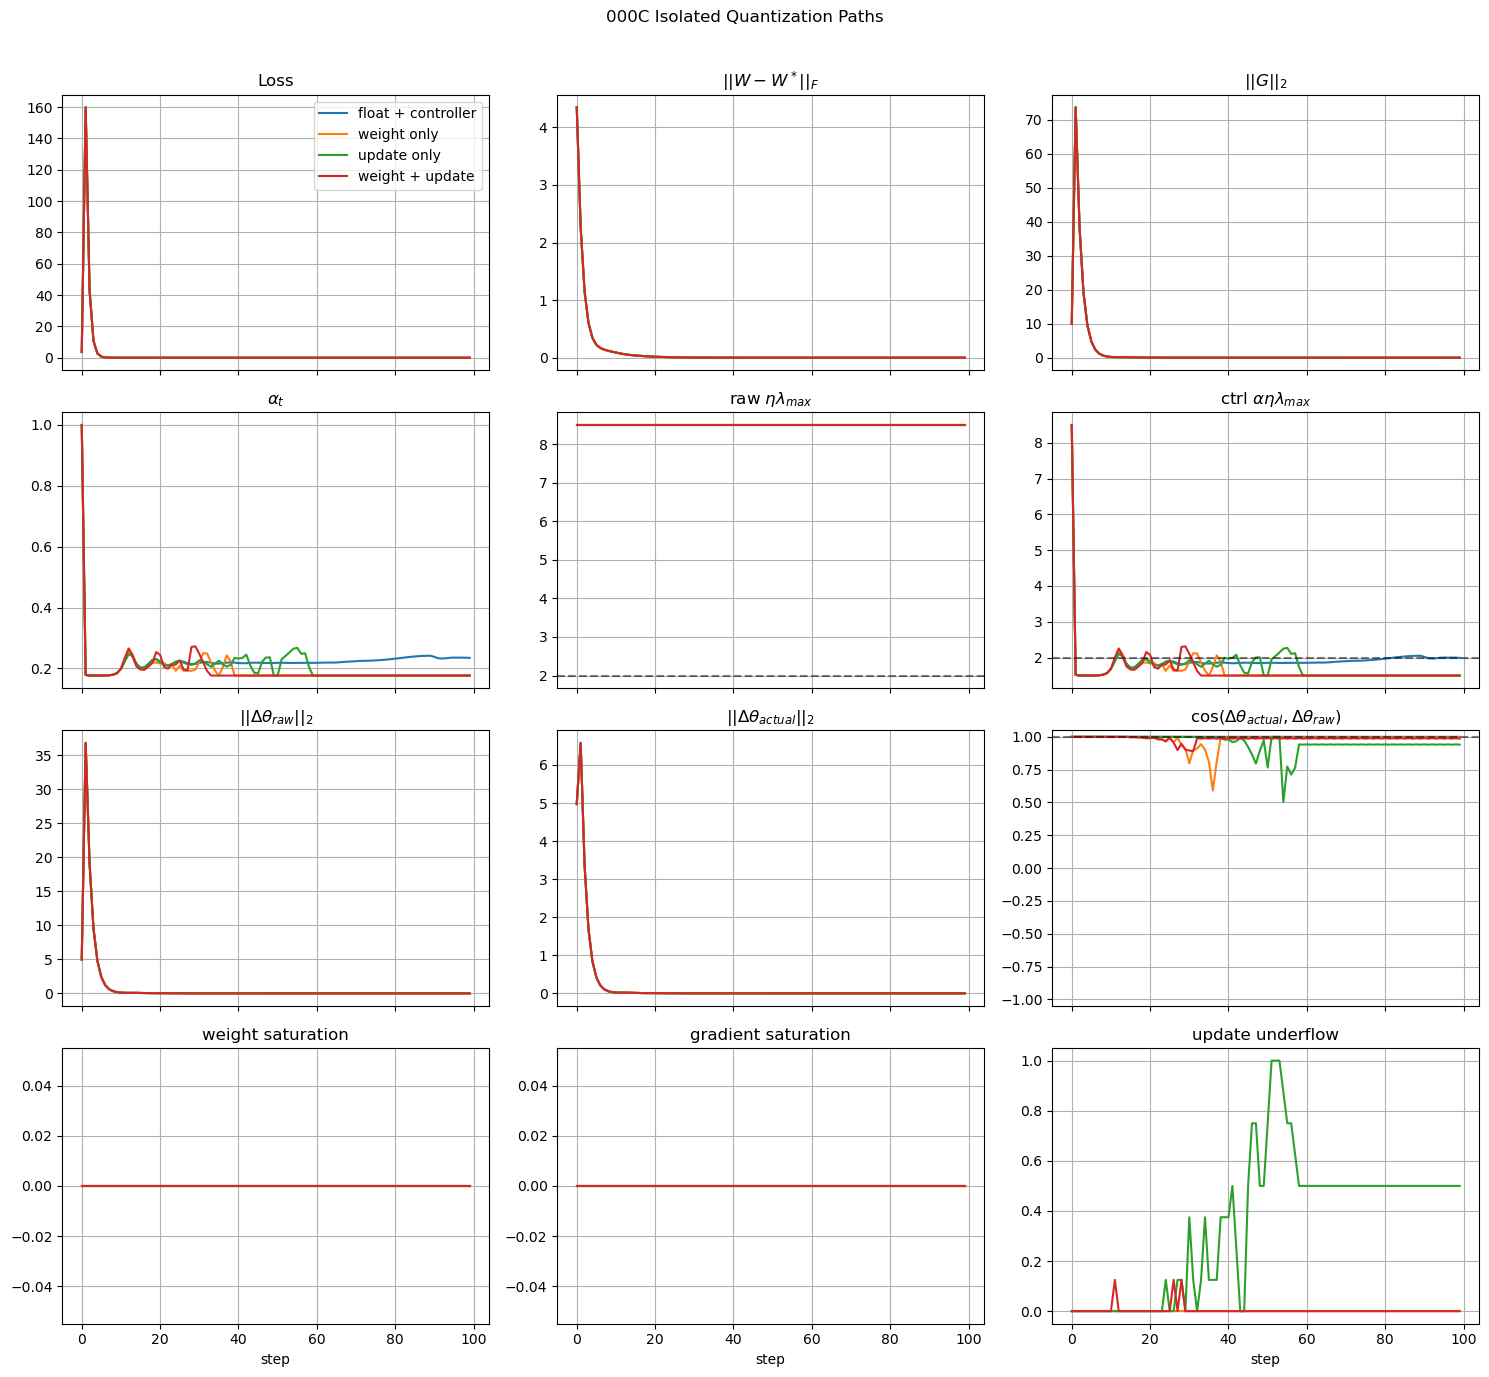

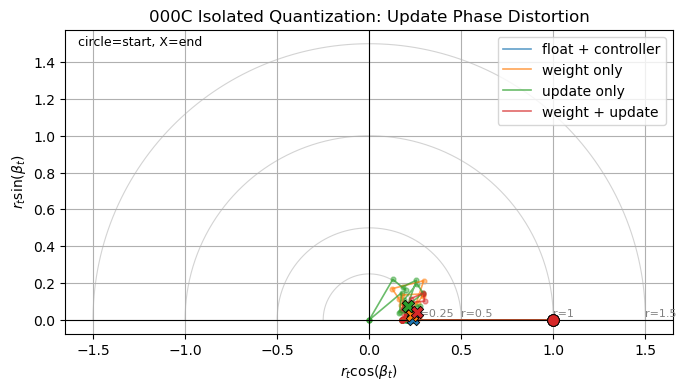

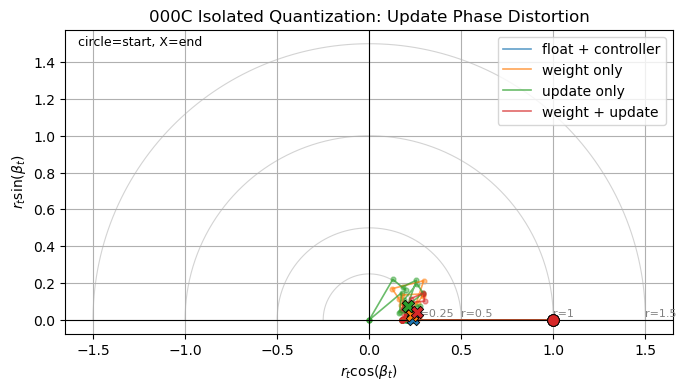

In [13]:
isolated_runs = [
    float_run,
    run_warmup_then_drift("weight only", make_precision_map("weight_only"), use_controller=True),
    run_warmup_then_drift("update only", make_precision_map("update_only"), use_controller=True),
    run_warmup_then_drift("weight + update", make_precision_map("weight_update"), use_controller=True),
]

plot_drift_comparison(
    isolated_runs,
    "000C Isolated Quantization Paths",
    "000c_isolated_quantization_paths.png",
)

plot_update_phase(
    isolated_runs,
    "000C Isolated Quantization: Update Phase Distortion",
    "000c_isolated_quantization_phase.png",
)

## 000C.4: Full Fake-Fixed-Point With Wide Rails

Wide rails should behave similarly to float, possibly with a small quantization floor.

[INFO] - Reinitialized kernel for layer dense0 with initializer GlorotUniform


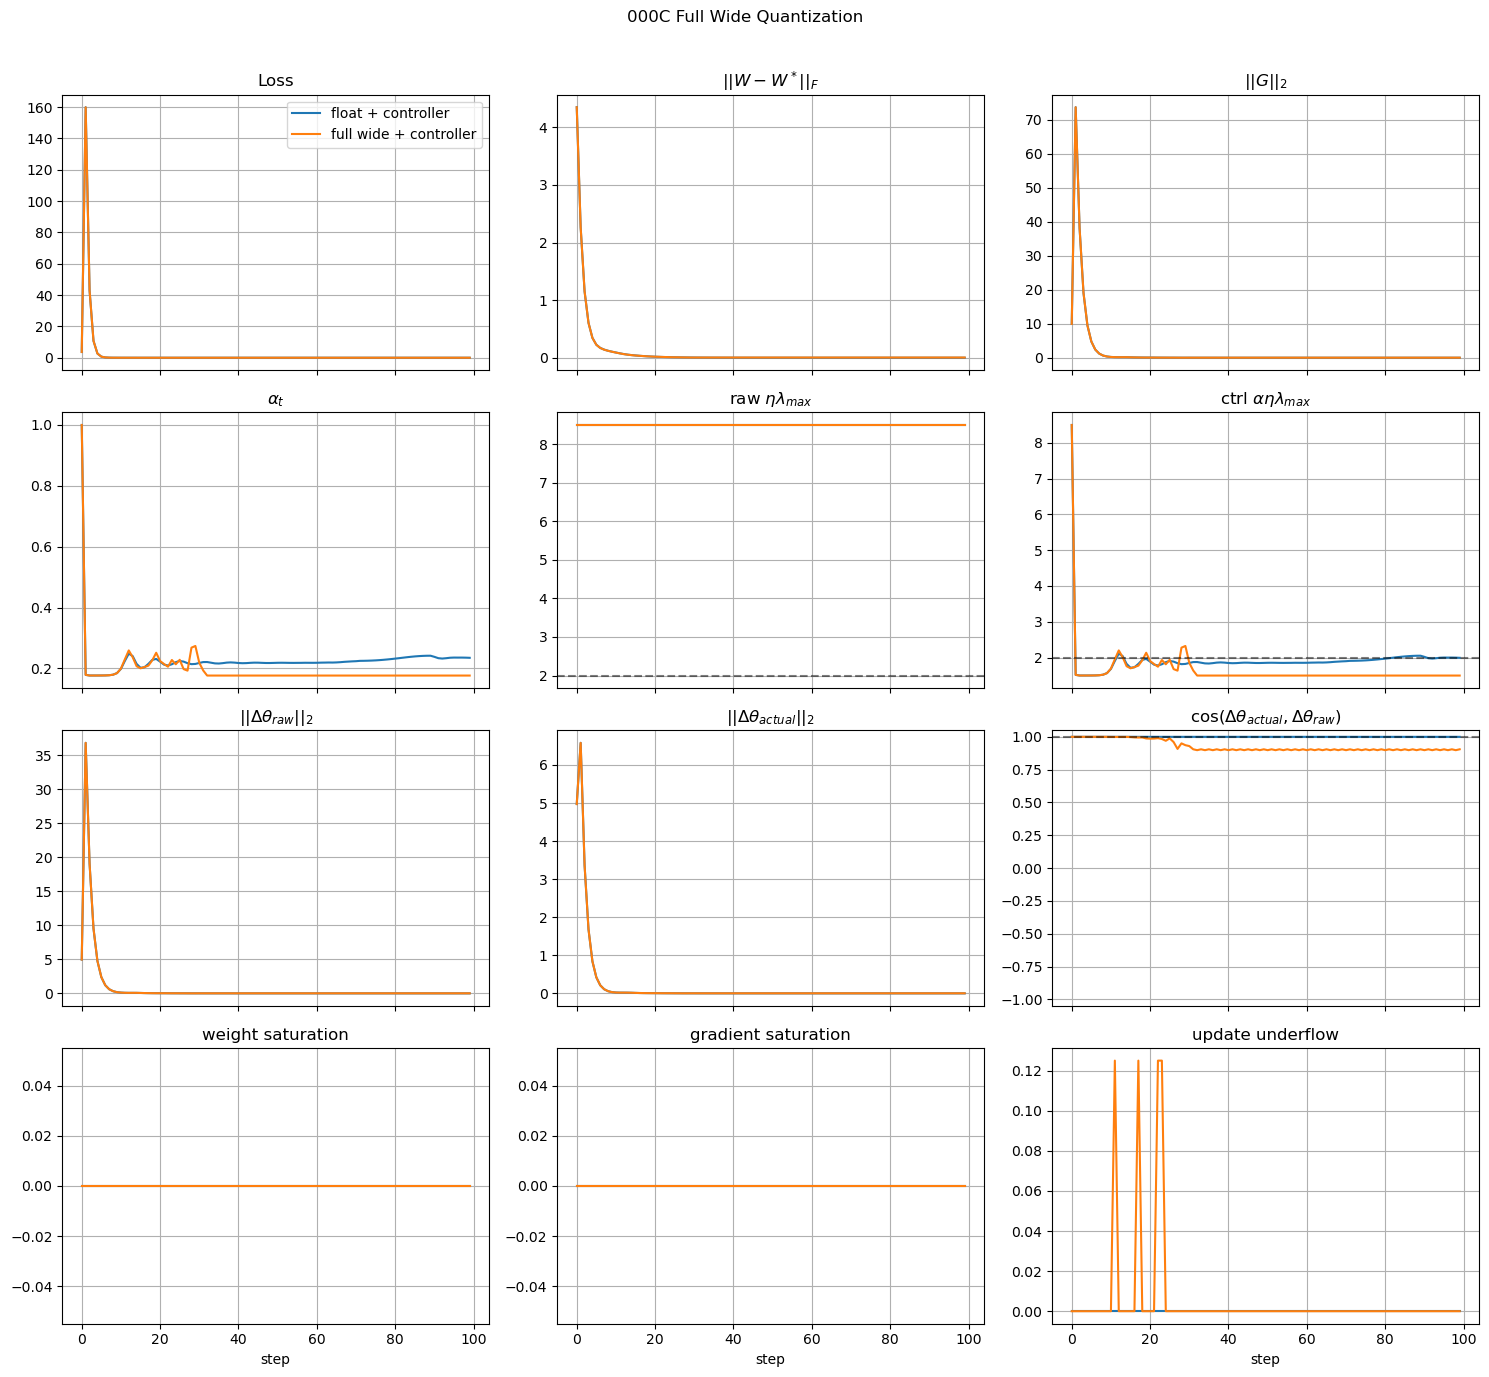

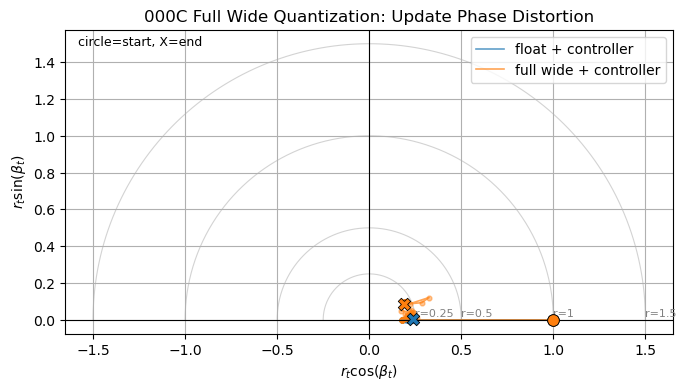

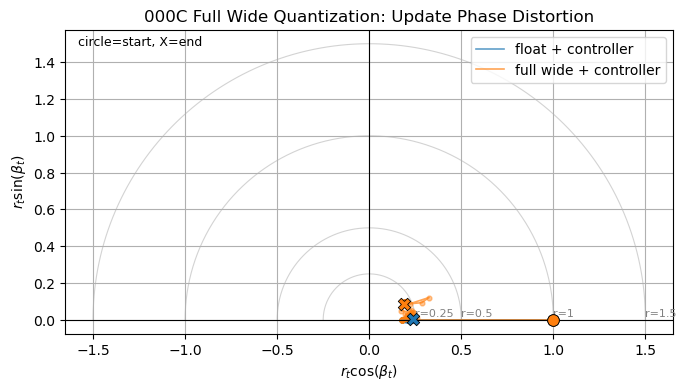

In [14]:
wide_run = run_warmup_then_drift(
    "full wide + controller",
    make_precision_map("full_wide"),
    use_controller=True,
)

plot_drift_comparison(
    [float_run, wide_run],
    "000C Full Wide Quantization",
    "000c_full_wide_quantization.png",
)

plot_update_phase(
    [float_run, wide_run],
    "000C Full Wide Quantization: Update Phase Distortion",
    "000c_full_wide_quantization_phase.png",
)

## 000C.5: Full Fake-Fixed-Point With Tight Rails

Tight rails should expose saturation and/or update underflow. This is the first hardware-style failure test.

[INFO] - Reinitialized kernel for layer dense0 with initializer GlorotUniform


[INFO] - Reinitialized kernel for layer dense0 with initializer GlorotUniform


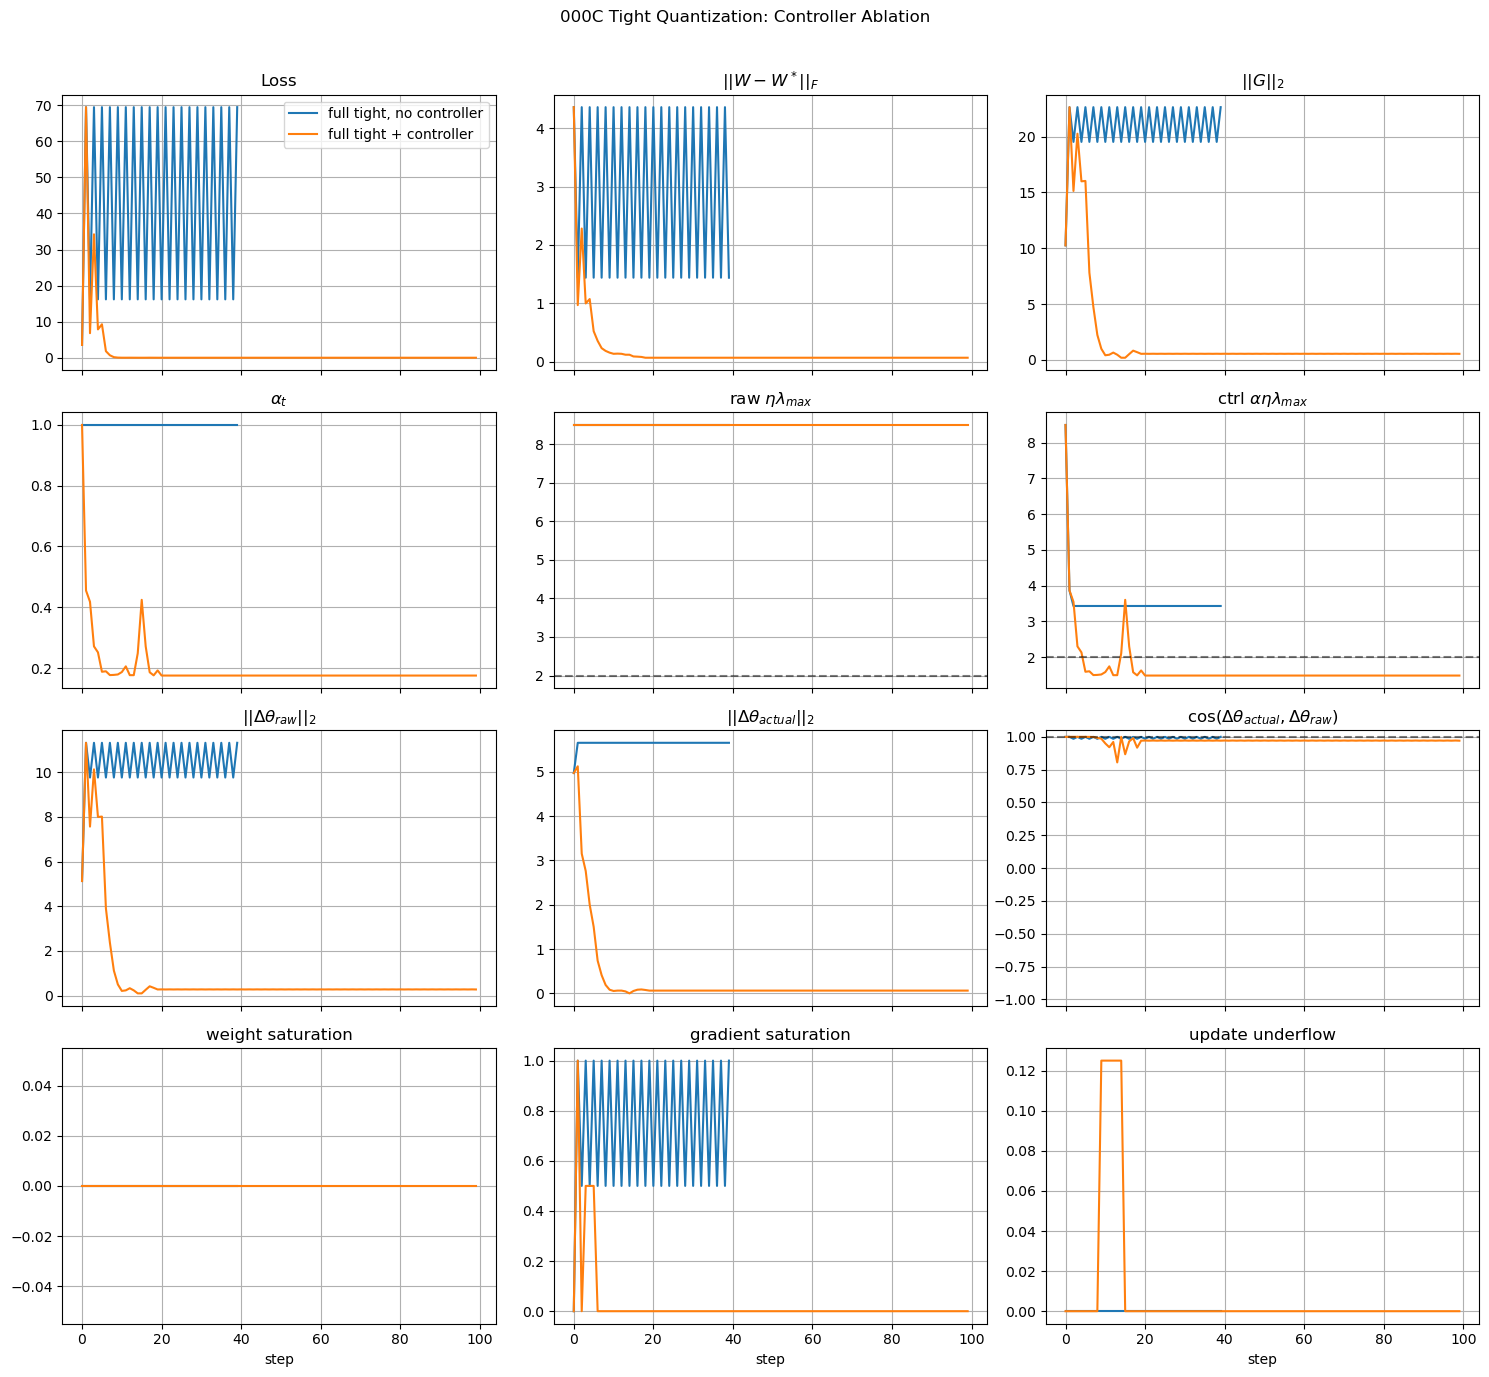

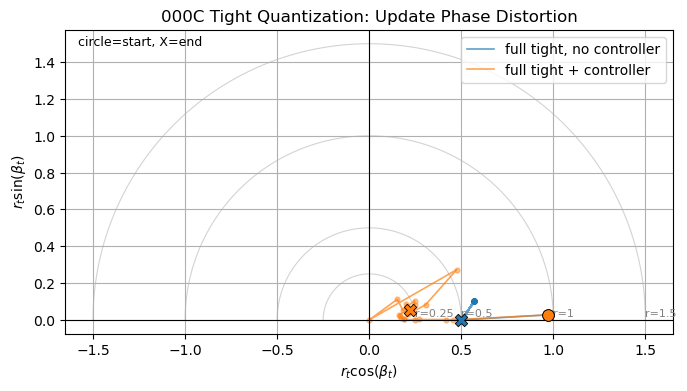

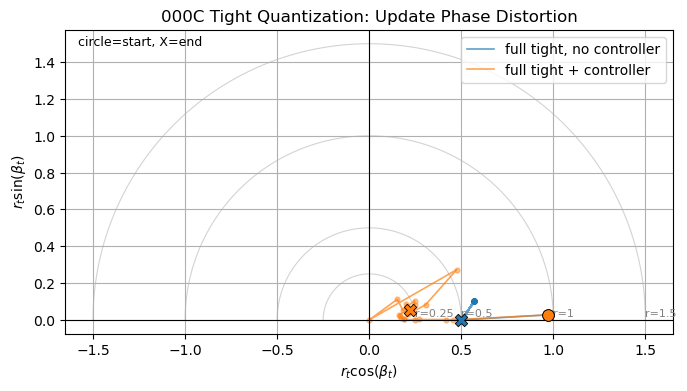

In [15]:
tight_no_controller = run_warmup_then_drift(
    "full tight, no controller",
    make_precision_map("full_tight"),
    use_controller=False,
    drift_epochs=40,
)

tight_controller = run_warmup_then_drift(
    "full tight + controller",
    make_precision_map("full_tight"),
    use_controller=True,
    drift_epochs=100,
)

plot_drift_comparison(
    [tight_no_controller, tight_controller],
    "000C Tight Quantization: Controller Ablation",
    "000c_tight_quantization_controller_ablation.png",
)

plot_update_phase(
    [tight_no_controller, tight_controller],
    "000C Tight Quantization: Update Phase Distortion",
    "000c_tight_quantization_phase.png",
)

## Interpretation Checklist

Use these questions when reading the plots:

- Does wide quantization behave like float?
- Does update quantization create update underflow?
- Does weight quantization create a nonzero error floor?
- Do tight rails cause saturation before or after divergence?
- Does the controller stabilize the tight run by learning, or only by shrinking updates to zero?
- Does `actual_update_norm` remain nonzero after stabilization?
- Does `update_cosine` remain near 1, or does quantization distort the update direction?
- Does the update phase portrait stay near the positive real axis, or does it move inward/away from the axis?
- Does `alpha_t eta lambda_max` remain below the stability limit after drift?

A successful quantized controller run should be bounded and should keep nonzero applied updates. A run that is stable only because updates underflow to zero is not a learning success.